# Coffee Dialling Automation — Classification Model (Clean Version)

This notebook documents the cleaned classification workflow for the Coffee Dialling Automation project.

The purpose of this notebook is to test whether coffee quality classes can be predicted using **non-sensory**, physical, production, and categorical features.

The notebook is structured for final report use with clear headings, explanations, model outputs, and interpretation.

## 1. Project Context

The project uses the CQI Arabica coffee dataset to analyse coffee quality patterns. In this classification approach, the task is framed as a supervised machine learning problem.

Instead of predicting a continuous score, the model predicts a quality category:

- **High** quality
- **Medium** quality
- **Low** quality

A key design decision is that sensory features are removed from the model inputs. This is done because `Total Cup Points` is directly derived from sensory scores. If sensory features were kept, the model would indirectly learn the scoring formula instead of learning from independent production or physical indicators.

## 2. Import Libraries and Load Dataset

This section imports the required Python libraries and loads the raw Arabica dataset.

The file is read using `latin1` encoding because the dataset may contain special characters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
# If running locally, keep Arabica.csv in the same folder as this notebook.
try:
    raw_df = pd.read_csv("Arabica.csv", encoding="latin1")
except FileNotFoundError:
    raw_df = pd.read_csv("/mnt/data/Arabica.csv", encoding="latin1")

# Work on a copy to protect raw data
df = raw_df.copy()

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (207, 37)


,ID,Country/Region of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Number of Bags,Bag Weight,In-Country Partner,Harvest Year,Grading Date,Owner,Variety,Status,Processing Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration
0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,1,35 kg,Japan Coffee Exchange,2021 / 2022,"September 21st, 2022",Coffee Quality Union,Castillo,Completed,Double Anaerobic Washed,8.58,8.50,8.42,8.58,8.25,8.42,10.0,10,10,8.58,0,89.33,11.8,0,0,green,3,"September 21st, 2023"
1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,?????????,1,80 kg,Taiwan Coffee Laboratory ?????????????????????,2021 / 2022,"November 15th, 2022",Taiwan Coffee Laboratory ?????????????????????,Gesha,Completed,Washed / Wet,8.50,8.50,7.92,8.00,7.92,8.25,10.0,10,10,8.50,0,87.58,10.5,0,0,blue-green,0,"November 15th, 2023"
2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,19,25 kg,Taiwan Coffee Laboratory ?????????????????????,2021 / 2022,"November 15th, 2022",Taiwan Coffee Laboratory ?????????????????????,Java,Completed,Semi Washed,8.33,8.42,8.08,8.17,7.92,8.17,10.0,10,10,8.33,0,87.42,10.4,0,0,yellowish,2,"November 15th, 2023"
3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,1,22 kg,Japan Coffee Exchange,2022,"September 21st, 2022",Coffee Quality Union,Gesha,Completed,Washed / Wet,8.08,8.17,8.17,8.25,8.17,8.08,10.0,10,10,8.25,0,87.17,11.8,0,0,green,0,"September 21st, 2023"
4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,2,24 kg,Japan Coffee Exchange,2022,"March 6th, 2023",Coffee Quality Union,Red Bourbon,Completed,"Honey,Mossto",8.33,8.33,8.08,8.25,7.92,7.92,10.0,10,10,8.25,0,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024"


## 3. Basic Dataset Inspection

This step checks the structure of the raw dataset, including columns, data types, and missing values. This helps identify which fields need cleaning before modelling.

In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values above zero:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

Dataset shape: (207, 37)

Column names:
['ID', 'Country/Region of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration']

Missing values above zero:


ICO Number           132
Variety                6
Processing Method      5
Mill                   3
Farm Name              2
Region                 2
Altitude               1
Lot Number             1
Producer               1
dtype: int64

## 4. Remove Redundant and Leakage-Prone Columns

The raw dataset contains administrative, identifier, and constant-value columns that are not useful for classification.

The following columns are removed:

- **Identifier / administrative fields:** `ID`, `Farm Name`, `Lot Number`, `Mill`, `ICO Number`, `Owner`, etc.
- **Constant or near-constant sensory fields:** `Clean Cup`, `Sweetness`, `Defects`, `Uniformity`
- **Date fields with no modelling value:** `Grading Date`, `Expiration`

These columns either add noise, create high-cardinality problems, or provide no meaningful predictive signal.

In [3]:
drop_cols = [
    # constant / near-constant
    'Clean Cup', 'Sweetness', 'Defects', 'Uniformity',
    
    # identifiers / metadata / noisy text
    'ID', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number',
    'Company', 'Region', 'Producer', 'In-Country Partner',
    'Owner', 'Status', 'Certification Body', 'Certification Address',
    'Certification Contact',
    
    # date / expiry fields not useful for this model
    'Grading Date', 'Expiration'
]

df = df.drop(columns=drop_cols, errors='ignore')

print("Shape after dropping redundant columns:", df.shape)
print(df.columns.tolist())

Shape after dropping redundant columns: (207, 20)
['Country/Region of Origin', 'Altitude', 'Number of Bags', 'Bag Weight', 'Harvest Year', 'Variety', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Overall', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects']


## 5. Clean Numeric Features

Several columns are stored as text even though they represent numeric values. These are cleaned so they can be used by the model.

Cleaning performed:

- `Altitude`: ranges such as `1700-1930` are converted to midpoint values.
- `Bag Weight`: `kg` is removed and values are converted to numeric.
- `Harvest Year`: ranges such as `2021 / 2022` are simplified by keeping the most recent year.
- `Number of Bags`: log transformation is applied to reduce skew.

In [4]:
def clean_altitude(value):
    try:
        value = str(value).strip()
        if '-' in value:
            low, high = value.split('-')
            return (float(low) + float(high)) / 2
        return float(value)
    except Exception:
        return np.nan


def clean_year(value):
    try:
        value = str(value).strip()
        if '/' in value:
            return int(value.split('/')[-1].strip())
        return int(value)
    except Exception:
        return np.nan

# Clean Altitude
if 'Altitude' in df.columns:
    df['Altitude'] = df['Altitude'].apply(clean_altitude)
    df['Altitude'] = df['Altitude'].fillna(df['Altitude'].median())

# Clean Bag Weight
if 'Bag Weight' in df.columns:
    df['Bag Weight'] = df['Bag Weight'].astype(str).str.replace(' kg', '', regex=False)
    df['Bag Weight'] = pd.to_numeric(df['Bag Weight'], errors='coerce')
    df['Bag Weight'] = df['Bag Weight'].fillna(df['Bag Weight'].median())

# Clean Harvest Year
if 'Harvest Year' in df.columns:
    df['Harvest Year'] = df['Harvest Year'].apply(clean_year)
    df['Harvest Year'] = df['Harvest Year'].fillna(df['Harvest Year'].median())

# Log transform Number of Bags
if 'Number of Bags' in df.columns:
    df['Number of Bags Log'] = np.log1p(df['Number of Bags'])
    df = df.drop(columns=['Number of Bags'])

print("Numeric feature cleaning completed")
df[['Altitude', 'Bag Weight', 'Harvest Year', 'Number of Bags Log']].head()

Numeric feature cleaning completed


,Altitude,Bag Weight,Harvest Year,Number of Bags Log
0,1815.0,35,2022,0.693147
1,1200.0,80,2022,0.693147
2,1300.0,25,2022,2.995732
3,1900.0,22,2022,0.693147
4,1975.0,24,2022,1.098612


## 6. Clean and Simplify Categorical Features

Categorical features must be cleaned before one-hot encoding.

Cleaning performed:

- `Country/Region of Origin` is renamed to `Country`.
- Missing categorical values are filled as `unknown`.
- Country names and colour labels are standardised.
- Processing methods are simplified into broader categories.
- Rare varieties are grouped into `other` to reduce sparse encoding.

In [5]:
# Rename country column
if 'Country/Region of Origin' in df.columns:
    df = df.rename(columns={'Country/Region of Origin': 'Country'})

# Fill missing categorical values
categorical_cols_to_fill = ['Country', 'Variety', 'Processing Method', 'Color']
for col in categorical_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()

# Standardise country labels
if 'Country' in df.columns:
    df['Country'] = df['Country'].replace({
        'tanzania, united republic of': 'tanzania',
        'united states (hawaii)': 'usa'
    })

# Standardise colour labels
if 'Color' in df.columns:
    df['Color'] = df['Color'].replace({
        'yellow green': 'yellow-green',
        'yellow- green': 'yellow-green',
        'yello-green': 'yellow-green',
        'yellowish': 'yellow'
    })

# Simplify processing method
def simplify_processing(value):
    value = str(value).lower()
    if 'washed' in value or 'lavado' in value or 'hulling' in value:
        return 'washed'
    elif 'natural' in value or 'dry' in value:
        return 'natural'
    elif 'honey' in value or 'pulped' in value or 'mossto' in value:
        return 'honey'
    else:
        return 'other'

if 'Processing Method' in df.columns:
    df['Processing Method'] = df['Processing Method'].apply(simplify_processing)

# Group rare varieties
if 'Variety' in df.columns:
    variety_counts = df['Variety'].value_counts()
    common_varieties = variety_counts[variety_counts >= 5].index
    df['Variety'] = df['Variety'].where(df['Variety'].isin(common_varieties), 'other')

print("Categorical cleaning completed")
print("Processing Method distribution:")
print(df['Processing Method'].value_counts())

Categorical cleaning completed
Processing Method distribution:
Processing Method
washed     128
natural     72
other        6
honey        1
Name: count, dtype: int64


## 7. Create Classification Target

The dataset does not originally contain Low, Medium, and High quality labels. Therefore, a new target variable called `Quality` is created from `Total Cup Points`.

The class thresholds used in this notebook are:

| Quality Class | Total Cup Points Range |
|---|---|
| Low | < 82 |
| Medium | 82 to < 85 |
| High | >= 85 |

This step converts the problem into a supervised classification task.

**Important limitation:** This binning process creates artificial class boundaries. Coffees close to the boundary may be almost identical in real quality but assigned to different classes.

Quality class distribution:


Quality
Medium    131
High       48
Low        28
Name: count, dtype: int64

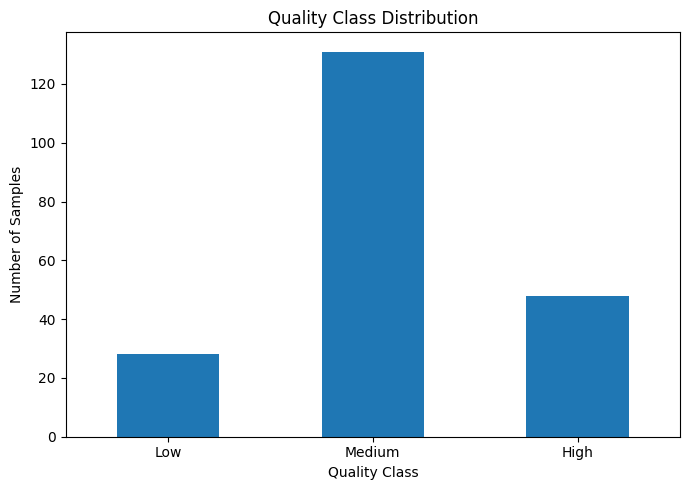

In [6]:
def classify_quality(score):
    if score >= 85:
        return 'High'
    elif score >= 82:
        return 'Medium'
    else:
        return 'Low'

# Create target class
df['Quality'] = df['Total Cup Points'].apply(classify_quality)

print("Quality class distribution:")
class_distribution = df['Quality'].value_counts()
display(class_distribution)

# Visualise class distribution
plt.figure(figsize=(7, 5))
class_distribution.loc[['Low', 'Medium', 'High']].plot(kind='bar')
plt.title("Quality Class Distribution")
plt.xlabel("Quality Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Output Explanation

The class distribution shows that the dataset is imbalanced. Most coffee samples fall into the `Medium` class, while `Low` and `High` have fewer samples.

This imbalance is important because the model may learn to favour the majority class instead of correctly identifying minority classes.

## 8. Remove Sensory Leakage Features

The sensory features are removed before modelling because `Total Cup Points` is calculated from sensory scores.

Removed leakage-prone features:

- Aroma
- Flavor
- Aftertaste
- Acidity
- Body
- Balance
- Overall
- Total Cup Points

This ensures the model uses only independent physical, production, and categorical information.

In [7]:
leakage_cols = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
    'Balance', 'Overall', 'Total Cup Points'
]

model_df = df.drop(columns=leakage_cols, errors='ignore')

print("Dataset shape after removing leakage features:", model_df.shape)
print(model_df.columns.tolist())

Dataset shape after removing leakage features: (207, 13)
['Country', 'Altitude', 'Bag Weight', 'Harvest Year', 'Variety', 'Processing Method', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Number of Bags Log', 'Quality']


## 9. One-Hot Encode Categorical Features

Machine learning models require numeric input. Therefore, categorical features are converted into numeric dummy variables using one-hot encoding.

In [8]:
categorical_cols = ['Country', 'Variety', 'Processing Method', 'Color']
existing_categorical_cols = [col for col in categorical_cols if col in model_df.columns]

encoded_df = pd.get_dummies(
    model_df,
    columns=existing_categorical_cols,
    drop_first=True
)

print("Encoded dataset shape:", encoded_df.shape)
print("Object columns remaining:")
print(encoded_df.select_dtypes(include='object').columns)
encoded_df.head()

Encoded dataset shape: (207, 50)
Object columns remaining:
Index(['Quality'], dtype='object')


,Altitude,Bag Weight,Harvest Year,Moisture Percentage,Category One Defects,Quakers,Category Two Defects,Number of Bags Log,Quality,Country_colombia,Country_costa rica,Country_el salvador,Country_ethiopia,Country_guatemala,Country_honduras,Country_indonesia,Country_kenya,Country_laos,Country_madagascar,Country_mexico,Country_myanmar,Country_nicaragua,Country_panama,Country_peru,Country_taiwan,Country_tanzania,Country_thailand,Country_uganda,Country_usa,Country_vietnam,Variety_catimor,Variety_catuai,Variety_caturra,Variety_ethiopian heirlooms,Variety_gesha,Variety_other,Variety_sl34,Variety_typica,Variety_unknown,Processing Method_natural,Processing Method_other,Processing Method_washed,Color_bluish-green,Color_browish-green,Color_brownish,Color_green,Color_greenish,Color_pale yellow,Color_yellow,Color_yellow-green
0,1815.0,35,2022,11.8,0,0,3,0.693147,High,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,1200.0,80,2022,10.5,0,0,0,0.693147,High,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,1300.0,25,2022,10.4,0,0,2,2.995732,High,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False
3,1900.0,22,2022,11.8,0,0,0,0.693147,High,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
4,1975.0,24,2022,11.6,0,2,2,1.098612,High,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True


## 10. Separate Features and Target

`X` contains the model input features.

`y` contains the target quality class.

In [9]:
X = encoded_df.drop(columns=['Quality'])
y = encoded_df['Quality']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", y.unique())

X shape: (207, 49)
y shape: (207,)
Target classes: ['High' 'Medium' 'Low']


## 11. Train-Test Split

The dataset is split into training and testing sets using an 80/20 ratio.

`stratify=y` is used to preserve the Low, Medium, and High class distribution in both training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training feature shape: (165, 49)
Testing feature shape: (42, 49)

Training class distribution:
Quality
Medium    105
High       38
Low        22
Name: count, dtype: int64

Testing class distribution:
Quality
Medium    26
High      10
Low        6
Name: count, dtype: int64


## 12. Baseline Random Forest Classifier

A Random Forest Classifier is used as the baseline model.

Reasons for selecting Random Forest:

- Works with mixed numeric and encoded categorical data
- Handles non-linear relationships
- Does not require feature scaling
- Provides feature importance values
- Performs reasonably well as a baseline model on small tabular datasets

In [11]:
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline model trained successfully")
print("Baseline Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))

Baseline model trained successfully
Baseline Accuracy: 0.619


## 13. Baseline Model Evaluation

The baseline model is evaluated using:

- Accuracy
- Confusion matrix
- Classification report

Accuracy alone is not enough because the dataset is imbalanced. Precision, recall, and F1-score provide a better understanding of class-level performance.

In [12]:
print("Baseline Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("\nBaseline Confusion Matrix:")
print(confusion_matrix(y_test, baseline_pred, labels=['Low', 'Medium', 'High']))
print("\nBaseline Classification Report:")
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.619

Baseline Confusion Matrix:
[[ 1  5  0]
 [ 3 21  2]
 [ 0  6  4]]

Baseline Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.40      0.50        10
         Low       0.25      0.17      0.20         6
      Medium       0.66      0.81      0.72        26

    accuracy                           0.62        42
   macro avg       0.52      0.46      0.47        42
weighted avg       0.60      0.62      0.60        42



### Output Explanation

The baseline model gives an initial view of classification performance. However, because the dataset has more `Medium` samples than `Low` or `High`, the model may predict the majority class more confidently than minority classes.

## 14. Balanced Random Forest Classifier

A second Random Forest model is trained using `class_weight='balanced'`.

This gives higher importance to minority classes and checks whether class imbalance is the main reason for weak performance.

In [13]:
balanced_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)

print("Balanced model trained successfully")
print("Balanced Accuracy:", round(accuracy_score(y_test, balanced_pred), 4))

Balanced model trained successfully
Balanced Accuracy: 0.619


## 15. Balanced Model Evaluation

This is the final classification model evaluation used for reporting.

In [14]:
print("Balanced Accuracy:", round(accuracy_score(y_test, balanced_pred), 4))
print("\nBalanced Confusion Matrix:")
print(confusion_matrix(y_test, balanced_pred, labels=['Low', 'Medium', 'High']))
print("\nBalanced Classification Report:")
print(classification_report(y_test, balanced_pred))

Balanced Accuracy: 0.619

Balanced Confusion Matrix:
[[ 1  5  0]
 [ 3 21  2]
 [ 0  6  4]]

Balanced Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.40      0.50        10
         Low       0.25      0.17      0.20         6
      Medium       0.66      0.81      0.72        26

    accuracy                           0.62        42
   macro avg       0.52      0.46      0.47        42
weighted avg       0.60      0.62      0.60        42



### Output Explanation

If the balanced model does not significantly improve performance, this suggests that the issue is not only class imbalance. It indicates that the remaining non-sensory features do not contain enough strong predictive signal to reliably separate Low, Medium, and High quality classes.

## 16. Classification Accuracy Summary

This section creates a clean summary table for the final model.

In [15]:
accuracy = accuracy_score(y_test, balanced_pred)
precision = precision_score(y_test, balanced_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, balanced_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, balanced_pred, average='weighted', zero_division=0)

accuracy_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

accuracy_summary['Score'] = accuracy_summary['Score'].round(4)

display(accuracy_summary)

,Metric,Score
0,Accuracy,0.6190
1,Precision,0.6007
2,Recall,0.6190
3,F1 Score,0.5959


## 17. Correct vs Misclassified Predictions

This section identifies which test samples were correctly classified and which were misclassified.

This is useful for the report because it gives a clear visual summary of model performance.

In [16]:
results_df = pd.DataFrame({
    'Actual Quality Class': y_test.values,
    'Predicted Quality Class': balanced_pred
})

results_df['Prediction Status'] = np.where(
    results_df['Actual Quality Class'] == results_df['Predicted Quality Class'],
    'Correctly Classified',
    'Misclassified'
)

print("Total test samples:", len(results_df))
print("Correctly classified:", (results_df['Prediction Status'] == 'Correctly Classified').sum())
print("Misclassified:", (results_df['Prediction Status'] == 'Misclassified').sum())

display(results_df.head(10))

Total test samples: 42
Correctly classified: 26
Misclassified: 16


,Actual Quality Class,Predicted Quality Class,Prediction Status
0,High,High,Correctly Classified
1,Medium,Medium,Correctly Classified
2,Medium,Medium,Correctly Classified
3,Medium,Medium,Correctly Classified
4,High,High,Correctly Classified
5,Medium,Medium,Correctly Classified
6,High,Medium,Misclassified
7,Medium,Medium,Correctly Classified
8,Medium,Medium,Correctly Classified
9,Medium,Medium,Correctly Classified


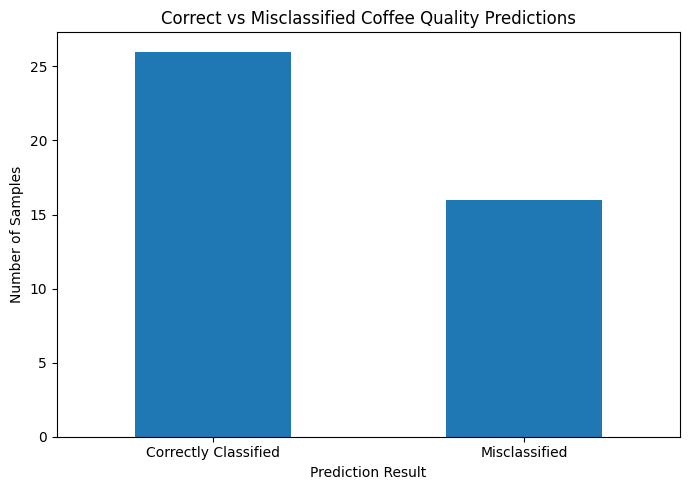

In [17]:
plt.figure(figsize=(7, 5))
results_df['Prediction Status'].value_counts().plot(kind='bar')
plt.title("Correct vs Misclassified Coffee Quality Predictions")
plt.xlabel("Prediction Result")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Output Explanation

This chart shows the number of correct and incorrect predictions made by the final classification model. A large number of misclassified samples supports the conclusion that the classification approach is limited by weak feature-target relationships.

## 18. Confusion Matrix Heatmap

The confusion matrix shows how many samples from each actual class were predicted as Low, Medium, or High.

This is one of the most important visuals for the final report.

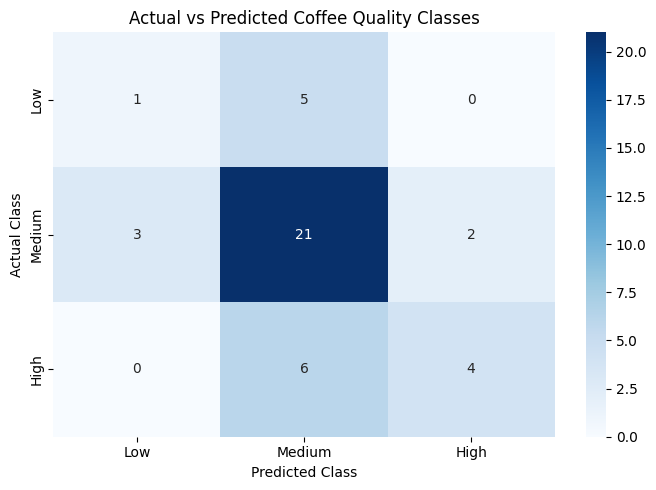

In [18]:
class_labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, balanced_pred, labels=class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Actual vs Predicted Coffee Quality Classes")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Output Explanation

The diagonal cells represent correct predictions, while off-diagonal cells represent misclassifications.

If many samples are misclassified as `Medium`, it suggests that the model struggles to separate boundary cases because most coffees are specialty-grade and clustered within a narrow score range.

## 19. Feature Importance Analysis

Feature importance shows which non-sensory features contributed most to the model's classification decisions.

This does not mean these features are strong enough for reliable prediction, but it helps explain what the model relied on.

In [19]:
feature_importance = pd.Series(
    balanced_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 important features:")
display(feature_importance.head(10).to_frame(name='Importance'))

Top 10 important features:


,Importance
Moisture Percentage,0.128245
Altitude,0.116939
Bag Weight,0.081969
Number of Bags Log,0.078729
Category Two Defects,0.078615
Variety_gesha,0.051198
Quakers,0.042359
Variety_other,0.041816
Harvest Year,0.029672
Country_taiwan,0.028952


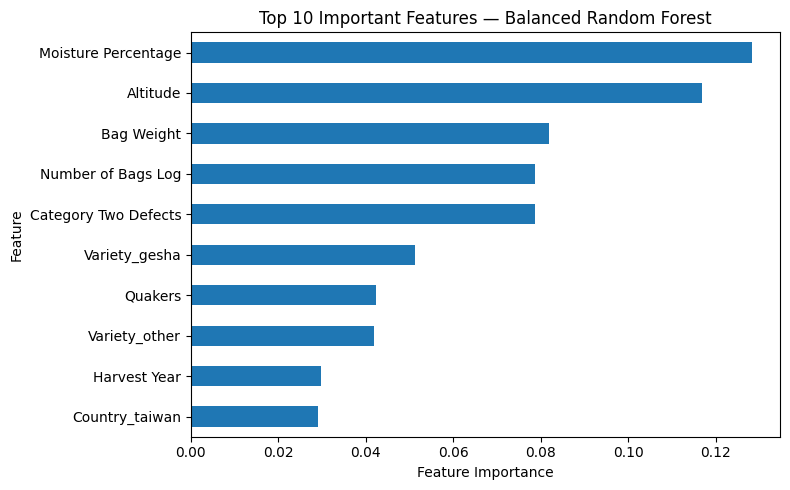

In [20]:
plt.figure(figsize=(8, 5))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Important Features — Balanced Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Output Explanation

The feature importance plot helps identify which physical or categorical features had the strongest influence on the model.

However, because the overall model performance is limited, feature importance should be interpreted as exploratory insight rather than strong predictive evidence.

## 20. Final Classification Findings

The classification approach was technically implemented correctly, but its performance was limited.

### Key Findings

1. The dataset is small, with only 207 samples.
2. The quality classes are artificially created from `Total Cup Points`.
3. The dataset contains mainly specialty-grade coffees, so quality differences are narrow.
4. Sensory features had to be removed to avoid leakage.
5. The remaining non-sensory features were not strong enough to reliably classify quality.

### Final Conclusion

The classification model is useful as an experimental approach, but it is not suitable as the final project solution. Its limitations helped justify the project transition toward unsupervised clustering, which produced more meaningful flavour profile insights.

## 21. Save Outputs

The processed dataset, accuracy summary, results table, and feature importance table are saved for reporting and GitHub documentation.

In [21]:
encoded_df.to_csv("classification_encoded_dataset.csv", index=False)
accuracy_summary.to_csv("classification_accuracy_summary.csv", index=False)
results_df.to_csv("classification_prediction_results.csv", index=False)
feature_importance.to_csv("classification_feature_importance.csv", header=['Importance'])

print("Saved outputs:")
print("- classification_encoded_dataset.csv")
print("- classification_accuracy_summary.csv")
print("- classification_prediction_results.csv")
print("- classification_feature_importance.csv")

Saved outputs:
- classification_encoded_dataset.csv
- classification_accuracy_summary.csv
- classification_prediction_results.csv
- classification_feature_importance.csv
